# Fixed-support MAML plots

This notebook plots selected MAML checkpoints for linear regression and decision tree runs. Edit only the small model lists in each task section: add one dictionary per curve with `label`, `run`, and `checkpoint`.

`checkpoint` can be `"latest"` for `state.pt` or an integer step for `model_<step>.pt`.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns

# Make the notebook work whether it is launched from the repo root or EvalNotebooks/.
CWD = Path.cwd().resolve()
if (CWD / "src").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "src").exists():
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = Path("/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism").resolve()

os.chdir(REPO_ROOT)
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eval import get_model_from_run, get_run_metrics
from plot_meta_paper_figure import TASK_SPECS, get_error_normalization, plot_task, rename_model

sns.set_theme("notebook", "darkgrid")

PLOT_USE_CACHE = True
ICL_EVAL_NAME = "standard"
MAML_EVAL_NAME = "maml"

RUN_ROOTS = {
    "icl": {
        "linear_regression": REPO_ROOT / "models" / "linear_regression",
        "decision_tree": REPO_ROOT / "models" / "decision_tree",
    },
    "maml": {
        "linear_regression": REPO_ROOT / "models" / "meta_linear_regression",
        "decision_tree": REPO_ROOT / "models" / "meta_decision_tree",
    },
}

# Batch-size overrides affect eval batching only, not the task distribution.
MAML_EVAL_OVERRIDES = {
    "linear_regression": {"batch_size": 64},
    "decision_tree": {"batch_size": 64},
}


In [2]:
def checkpoint_to_step(selector):
    if selector is None or selector == "latest":
        return -1
    if isinstance(selector, str):
        selector = selector.strip()
        if selector.lower() == "latest":
            return -1
        if selector.isdigit():
            return int(selector)
    if isinstance(selector, int):
        return selector
    raise ValueError(f"checkpoint must be 'latest' or an integer step, got {selector!r}")


def checkpoint_file_name(selector):
    step = checkpoint_to_step(selector)
    return "state.pt" if step == -1 else f"model_{step}.pt"


def config_kind(cfg):
    return cfg.get("kind", cfg.get("model_type", "maml"))


def eval_name_for_kind(kind):
    if kind == "icl":
        return ICL_EVAL_NAME
    if kind == "maml":
        return MAML_EVAL_NAME
    raise ValueError(f"Unknown model kind {kind!r}; use 'icl' or 'maml'.")


def resolve_run_path(task_name, cfg):
    run = cfg.get("run")
    if run in [None, ""]:
        return None
    kind = config_kind(cfg)
    run_path = Path(run)
    if not run_path.is_absolute():
        run_path = RUN_ROOTS[kind][task_name] / run_path
    return run_path


def resolve_model_configs(task_name, model_configs):
    resolved = []
    for cfg in model_configs:
        run_path = resolve_run_path(task_name, cfg)
        if run_path is None:
            print(f"Skipping {cfg.get('label', '<missing label>')}: no run folder set")
            continue
        checkpoint = cfg.get("checkpoint", "latest")
        checkpoint_path = run_path / checkpoint_file_name(checkpoint)
        if not checkpoint_path.exists():
            raise FileNotFoundError(f"Missing checkpoint for {cfg['label']}: {checkpoint_path}")
        kind = config_kind(cfg)
        resolved.append({
            **cfg,
            "kind": kind,
            "eval_name": eval_name_for_kind(kind),
            "run_path": run_path,
            "checkpoint_path": checkpoint_path,
        })
    return resolved


def normalize_and_rename_eval(raw_eval_metrics, run_path, label):
    _, conf = get_model_from_run(str(run_path), only_conf=True)
    normalization = get_error_normalization(conf)
    renamed = {}
    for model_name, model_metrics in raw_eval_metrics.items():
        renamed_model = rename_model(model_name, conf, transformer_label=label)
        renamed[renamed_model] = {
            key: [value / normalization for value in values]
            for key, values in model_metrics.items()
        }
    return renamed


def compute_curve(task_name, cfg, use_cache=PLOT_USE_CACHE):
    step = checkpoint_to_step(cfg.get("checkpoint", "latest"))
    label = cfg["label"]
    run_path = cfg["run_path"]
    eval_name = cfg["eval_name"]
    kind = cfg["kind"]
    print(f"computing/loading {task_name} | {label}: {cfg['checkpoint_path']} [{eval_name}]", flush=True)

    eval_kwargs_overrides = MAML_EVAL_OVERRIDES.get(task_name) if kind == "maml" else None
    metrics = get_run_metrics(
        str(run_path),
        step=step,
        cache=use_cache,
        skip_baselines=True,
        eval_names=[eval_name],
        eval_kwargs_overrides=eval_kwargs_overrides,
    )
    if eval_name not in metrics:
        raise KeyError(f"Eval {eval_name!r} not found for {run_path}")
    return normalize_and_rename_eval(metrics[eval_name], run_path, label)


def compute_task_curves(task_name, model_configs, use_cache=PLOT_USE_CACHE):
    combined = {}
    resolved = resolve_model_configs(task_name, model_configs)
    for cfg in resolved:
        combined.update(compute_curve(task_name, cfg, use_cache=use_cache))
    return combined


def plot_task_curves(task_name, model_configs, use_cache=PLOT_USE_CACHE, figsize=(8.5, 5.3)):
    metrics = compute_task_curves(task_name, model_configs, use_cache=use_cache)
    model_order = [cfg["label"] for cfg in model_configs if cfg.get("run") not in [None, ""]]
    print(f"curves available: {sorted(metrics.keys())}")

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
    plot_task(ax, task_name, metrics, model_order=model_order)
    display(fig)
    plt.close(fig)
    return metrics, fig


## Linear Regression

Add or remove dictionaries in `LINEAR_REGRESSION_MODELS`. Each entry creates one plotted curve.


In [7]:
PLOT_USE_CACHE = True

LINEAR_MAML_1STEP_LEARNED_LR_MULTI_K_RUN = "b7db4b1e-0f26-42b3-aa9b-6b9df4793916"
LINEAR_MAML_2STEP_LEARNED_LR_MULTI_K_RUN = "d0a4c860-5f8d-445b-997f-13543b957363"

LINEAR_REGRESSION_MODELS = [
    {
        "label": "TF (ICL)",
        "kind": "icl",
        "run": "12cc04e3-c831-488a-ac34-0d8388192559",
        "checkpoint": "latest",
    },
    {
        "label": "TF (MAML, 1 step, learned LR, multi-k)",
        "kind": "maml",
        "run": LINEAR_MAML_1STEP_LEARNED_LR_MULTI_K_RUN,
        "checkpoint": "latest",
    },
    {
        "label": "TF (MAML, 2 steps, learned LR, multi-k)",
        "kind": "maml",
        "run": LINEAR_MAML_2STEP_LEARNED_LR_MULTI_K_RUN,
        # state.pt for this run is empty; use the latest valid kept checkpoint.
        "checkpoint": 350000,
    },
    {
        "label": "TF (MAML, 1 step, learned LR, fixed length 25)",
        "kind": "maml",
        "run": "6f6c6d3e-54c7-4964-ab65-8696f046d322",
        "checkpoint": "latest",
    },
    {
        "label": "TF (MAML, 2 steps, learned LR, fixed length 25)",
        "kind": "maml",
        "run": "72bae06d-71bc-4479-9613-731907b15fa2",
        "checkpoint": "latest",
    },
    # {
    #     "label": "TF (MAML, fixed length 21, 5 steps)",
    #     "kind": "maml",
    #     "run": "maml_lr_fixed21-50bead48-f5c6-4d32-a3d8-99acf6697030",
    #     "checkpoint": "latest",
    # },
    {
        "label": "TF (ICL, fixed length 21, last)",
        "kind": "icl",
        "run": "icl_lr_len21_last-e5e9d6b8-e334-4e67-a386-c535744f745b",
        "checkpoint": "latest",
    },
    {
        "label": "TF (ICL, fixed length 21, all)",
        "kind": "icl",
        "run": "icl_lr_len21_all-8d6e8f4c-3380-4740-b612-cc1d0d8e0f73",
        "checkpoint": "latest",
    },
    {
        "label": "TF (MAML, fixed length 21, 2 steps)",
        "kind": "maml",
        "run": "maml_lr_fixed21_2step-f3bd835d-70f7-44f2-bfd4-d8275eb10185",
        "checkpoint": "latest",
    },
    
]


computing/loading linear_regression | TF (ICL): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/12cc04e3-c831-488a-ac34-0d8388192559/state.pt [standard]


12cc04e3-c831-488a-ac34-0d8388192559: 100%|██████████| 1/1 [00:00<00:00, 14768.68it/s]

computing/loading linear_regression | TF (MAML, 1 step, learned LR, multi-k): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/b7db4b1e-0f26-42b3-aa9b-6b9df4793916/state.pt [maml]



b7db4b1e-0f26-42b3-aa9b-6b9df4793916: 100%|██████████| 1/1 [00:00<00:00, 15827.56it/s]

computing/loading linear_regression | TF (MAML, 2 steps, learned LR, multi-k): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/d0a4c860-5f8d-445b-997f-13543b957363/model_350000.pt [maml]


...

computing/loading linear_regression | TF (ICL, fixed length 21, all): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/linear_regression/icl_lr_len21_all-8d6e8f4c-3380-4740-b612-cc1d0d8e0f73/state.pt [standard]



icl_lr_len21_all-8d6e8f4c-3380-4740-b612-cc1d0d8e0f73: 100%|██████████| 1/1 [00:00<00:00, 14820.86it/s]

computing/loading linear_regression | TF (MAML, fixed length 21, 2 steps): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_linear_regression/maml_lr_fixed21_2step-f3bd835d-70f7-44f2-bfd4-d8275eb10185/state.pt [maml]



maml_lr_fixed21_2step-f3bd835d-70f7-44f2-bfd4-d8275eb10185: 100%|██████████| 1/1 [00:00<00:00, 13273.11it/s]


curves available: ['3-Nearest Neighbors', 'Averaging', 'Least Squares', 'TF (ICL)', 'TF (ICL, fixed length 21, all)', 'TF (ICL, fixed length 21, last)', 'TF (MAML, 1 step, learned LR, fixed length 25)', 'TF (MAML, 1 step, learned LR, multi-k)', 'TF (MAML, 2 steps, learned LR, fixed length 25)', 'TF (MAML, 2 steps, learned LR, multi-k)', 'TF (MAML, fixed length 21, 2 steps)']


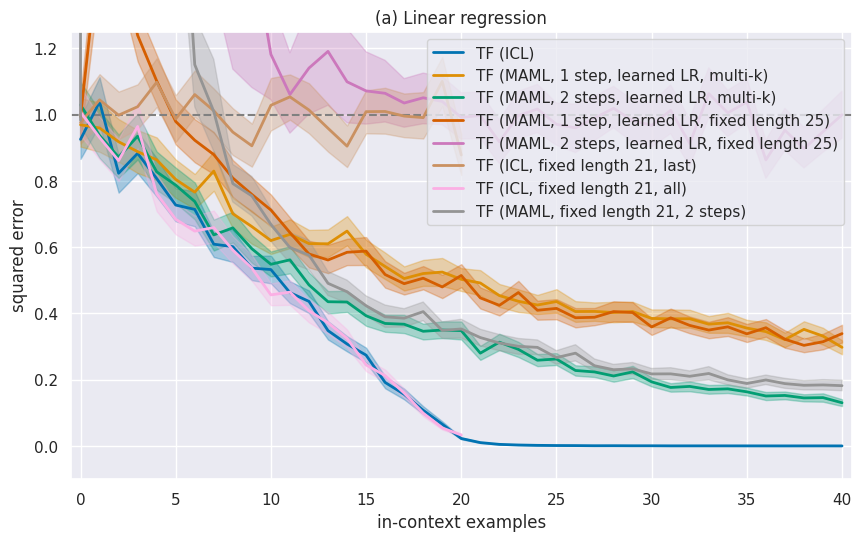

In [8]:
linear_regression_metrics, linear_regression_fig = plot_task_curves(
    "linear_regression",
    LINEAR_REGRESSION_MODELS,
    use_cache=PLOT_USE_CACHE,
)


## Decision Tree

Add or remove dictionaries in `DECISION_TREE_MODELS`. Each entry creates one plotted curve.


In [5]:
PLOT_USE_CACHE = True

TREE_MAML_1STEP_LEARNED_LR_RUN = "8a96b227-45c9-44b6-9170-da40b25b701a"
TREE_MAML_2STEP_LEARNED_LR_RUN = "8e762a47-93c1-4f16-a670-cfdd2e694f7b"
TREE_MAML_1STEP_LEARNED_LR_CHCKPOINT = 350000
TREE_MAML_2STEP_LEARNED_LR_CHECKPOINT = 200000

DECISION_TREE_MODELS = [
    {
        "label": "TF (ICL)",
        "kind": "icl",
        "run": "3cf4987d-48cd-407f-b874-a882c49e9331",
        "checkpoint": "latest",
    },
    {
        "label": "TF (MAML, 1 step, learned LR)",
        "kind": "maml",
        "run": TREE_MAML_1STEP_LEARNED_LR_RUN,
        "checkpoint": TREE_MAML_1STEP_LEARNED_LR_CHCKPOINT,
    },
    {
        "label": "TF (MAML, 2 steps, learned LR)",
        "kind": "maml",
        "run": TREE_MAML_2STEP_LEARNED_LR_RUN,
        "checkpoint": TREE_MAML_2STEP_LEARNED_LR_CHECKPOINT,
    },
    {
        "label": "TF (MAML, 1 step, learned LR, fixed length 65)",
        "kind": "maml",
        "run": "64d1bb87-4a43-49b8-8e94-6a505091811a",
        "checkpoint": "latest",
    },
    {
        "label": "TF (MAML, 2 steps, learned LR, fixed length 65)",
        "kind": "maml",
        "run": "0c8aadf1-e1db-4fcc-abf2-fa804bd01b2e",
        "checkpoint": "latest",
    },
]


computing/loading decision_tree | TF (ICL): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/decision_tree/3cf4987d-48cd-407f-b874-a882c49e9331/state.pt [standard]


/mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/src/eval.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(state_path, map_location=_checkpoint_map_lo

    computing standard for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


3cf4987d-48cd-407f-b874-a882c49e9331: 100%|██████████| 1/1 [00:01<00:00,  1.03s/it]

computing/loading decision_tree | TF (MAML, 1 step, learned LR): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/8a96b227-45c9-44b6-9170-da40b25b701a/model_350000.pt [maml]


...

computing/loading decision_tree | TF (MAML, 2 steps, learned LR, fixed length 65): /mnt/nlp/scratch/home/mpanwar/icl-bayesian-prism/models/meta_decision_tree/0c8aadf1-e1db-4fcc-abf2-fa804bd01b2e/state.pt [maml]



0c8aadf1-e1db-4fcc-abf2-fa804bd01b2e:   0%|          | 0/1 [00:00<?, ?it/s]

    computing maml for gpt2_embd=256_layer=12_head=8_pos_encodeFalse


0c8aadf1-e1db-4fcc-abf2-fa804bd01b2e: 100%|██████████| 1/1 [04:55<00:00, 295.98s/it]


curves available: ['TF (ICL)', 'TF (MAML, 1 step, learned LR)', 'TF (MAML, 1 step, learned LR, fixed length 65)', 'TF (MAML, 2 steps, learned LR)', 'TF (MAML, 2 steps, learned LR, fixed length 65)']


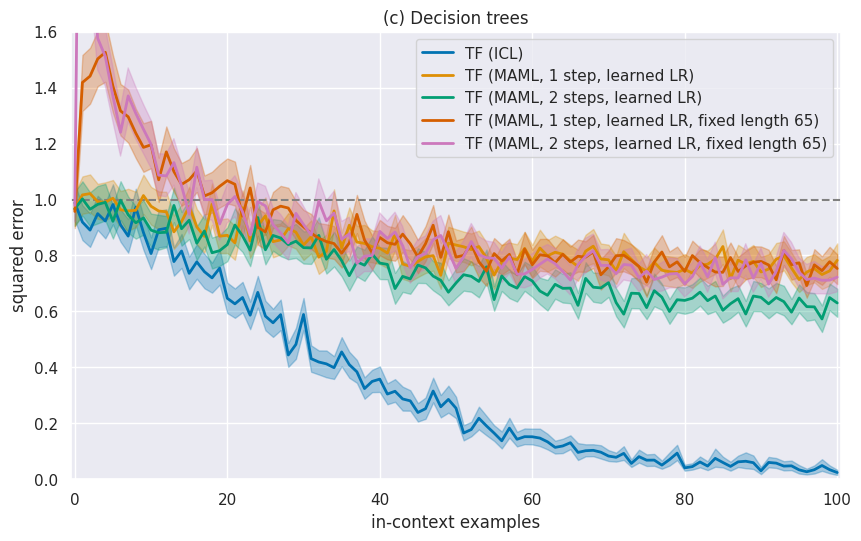

In [6]:
decision_tree_metrics, decision_tree_fig = plot_task_curves(
    "decision_tree",
    DECISION_TREE_MODELS,
    use_cache=PLOT_USE_CACHE,
)
